### Model Training

In [48]:
# %%
import os
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor

DATA_DIR = "/Users/trustanprice/Desktop/Personal/illinois-datathon-team015/data/processed"
RAW_DATA_DIR = "/Users/trustanprice/Desktop/Personal/illinois-datathon-team015/data/raw"

daily_df = pd.read_csv(os.path.join(DATA_DIR, "daily_df.csv"))
interval_df = pd.read_csv(os.path.join(DATA_DIR, "interval_df.csv"))
staff = pd.read_csv(os.path.join(DATA_DIR, "staffing_df.csv"))
template = pd.read_csv(os.path.join(RAW_DATA_DIR, "forecast_data.csv"))

# -----------------------------
# Parse daily date
# -----------------------------
daily_df["Date"] = pd.to_datetime(daily_df["Date"])

# -----------------------------
# Rebuild interval Date + slot
# interval_df has Month / Day / Interval, not Date
# These interval records are for 2025
# -----------------------------
mmap = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

interval_df["Day"] = pd.to_numeric(interval_df["Day"], errors="coerce")
interval_df["month_num"] = interval_df["Month"].map(mmap)

interval_df["Date"] = pd.to_datetime(
    dict(
        year=2025,
        month=interval_df["month_num"],
        day=interval_df["Day"]
    ),
    errors="coerce"
)

# rebuild slot if needed
if "slot" not in interval_df.columns:
    if "Interval" in interval_df.columns:
        interval_parsed = pd.to_datetime(
            interval_df["Interval"].astype(str),
            format="%H:%M:%S",
            errors="coerce"
        )

        bad = interval_parsed.isna()
        if bad.any():
            interval_parsed.loc[bad] = pd.to_datetime(
                interval_df.loc[bad, "Interval"].astype(str),
                format="%H:%M",
                errors="coerce"
            )

        interval_df["slot"] = (
            interval_parsed.dt.hour * 2
            + interval_parsed.dt.minute // 30
        )

# -----------------------------
# Clean staffing df
# current columns: Unnamed: 0, A, B, C, D
# -----------------------------
staff = staff.rename(
    columns={
        "Unnamed: 0": "Date",
        "A": "Staff_A",
        "B": "Staff_B",
        "C": "Staff_C",
        "D": "Staff_D"
    }
)

staff["Date"] = pd.to_datetime(staff["Date"])
staff = staff.sort_values("Date").reset_index(drop=True)

portfolios = ["A", "B", "C", "D"]

# -----------------------------
# Split into dicts
# -----------------------------
daily = {
    p: daily_df[daily_df["client"] == p].sort_values("Date").reset_index(drop=True)
    for p in portfolios
}

intervals = {
    p: interval_df[interval_df["client"] == p].sort_values(["Date", "slot"]).reset_index(drop=True)
    for p in portfolios
}

print({p: len(daily[p]) for p in portfolios})
print({p: len(intervals[p]) for p in portfolios})
print(f"staffing: {len(staff)} days")

{'A': 731, 'B': 731, 'C': 731, 'D': 731}
{'A': 4083, 'B': 4293, 'C': 4368, 'D': 4358}
staffing: 365 days


In [49]:

# %%
# -----------------------------
# Client-specific selected features
# Replace these with your final significance-based choices if needed
# -----------------------------
CLIENT_FEATURES = {
    "A": [
        "dow", "month", "wknd", "dow_s", "dow_c", "month_s", "month_c",
        "holiday", "month_start", "month_end",
        "Call Volume_l7", "Call Volume_l14", "Call Volume_l28",
        "Call Volume_r7", "Call Volume_r30", "Call Volume_ew",
        "CCT_l7", "CCT_l14", "CCT_r7", "CCT_r30", "CCT_ew",
        "Abandon Rate_l7", "Abandon Rate_r7",
        "agents"
    ],
    "B": [
        "dow", "dom", "month", "woy", "wknd", "dow_s", "dow_c", "month_s", "month_c",
        "holiday", "month_start", "month_end",
        "Call Volume_l7", "Call Volume_l14", "Call Volume_l28", "Call Volume_l365",
        "Call Volume_r7", "Call Volume_r30", "Call Volume_ew",
        "CCT_l7", "CCT_l14", "CCT_l28", "CCT_r7", "CCT_r30", "CCT_ew",
        "Abandon Rate_l7", "Abandon Rate_r7", "Abandon Rate_ew",
        "agents"
    ],
    "C": [
        "dow", "month", "wknd", "dow_s", "dow_c", "month_s", "month_c",
        "holiday",
        "Call Volume_l7", "Call Volume_l14", "Call Volume_l28",
        "Call Volume_r7", "Call Volume_r30",
        "CCT_l7", "CCT_r7", "CCT_r30", "CCT_ew",
        "Abandon Rate_l7", "Abandon Rate_r7",
        "agents"
    ],
    "D": [
        "dow", "dom", "month", "wknd", "mon", "dow_s", "dow_c", "month_s", "month_c",
        "holiday", "month_start", "month_end",
        "Call Volume_l7", "Call Volume_l14", "Call Volume_l28", "Call Volume_l365",
        "Call Volume_r7", "Call Volume_r30", "Call Volume_ew",
        "CCT_l7", "CCT_l14", "CCT_r7", "CCT_r30", "CCT_ew",
        "Abandon Rate_l7", "Abandon Rate_r7",
        "agents"
    ]
}

def feat_cols(df, client):
    skip = ["Date", "tgt_Call Volume", "tgt_CCT", "tgt_Abandon Rate"]
    cols = [c for c in CLIENT_FEATURES[client] if c in df.columns and c not in skip]
    if len(cols) == 0:
        raise ValueError(f"No valid selected features found for client {client}")
    return cols


In [50]:

# -----------------------------
# Interval models
# -----------------------------
interval_models = {}
abd_prof = {}
cct_prof = {}

for p in portfolios:
    df = intervals[p].copy()

    # rebuild dow from Date
    df["dow"] = df["Date"].dt.dayofweek

    # impute missing Call Volume using DOW + slot median
    imp = df.groupby(["dow", "slot"])["Call Volume"].median()

    missing_cv = df["Call Volume"].isna()
    if missing_cv.any():
        def fill_cv(row):
            return imp.get((row["dow"], row["slot"]), 0.0)
        df.loc[missing_cv, "Call Volume"] = df.loc[missing_cv].apply(fill_cv, axis=1)
        print(f"{p}: imputed {missing_cv.sum()} missing Call Volume slots")
    else:
        print(f"{p}: no missing Call Volume slots")

    # recompute daily total after imputation
    dtot = df.groupby("Date")["Call Volume"].sum().reset_index()
    dtot.columns = ["Date", "daily_cv"]
    df = df.merge(dtot, on="Date", how="left")

    # interval features
    df["is_peak"] = ((df["slot"] // 2 >= 9) & (df["slot"] // 2 <= 17)).astype(int)
    df["slot_sin"] = np.sin(2 * np.pi * df["slot"] / 48)
    df["slot_cos"] = np.cos(2 * np.pi * df["slot"] / 48)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
    df["month"] = df["Date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dom"] = df["Date"].dt.day
    df["dom_sin"] = np.sin(2 * np.pi * df["dom"] / 31)
    df["dom_cos"] = np.cos(2 * np.pi * df["dom"] / 31)

    icols = [
        "slot", "dow", "daily_cv", "is_peak",
        "slot_sin", "slot_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "dom_sin", "dom_cos"
    ]

    # numeric cleanup
    for col in icols + ["Call Volume", "Abandoned Calls", "CCT"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # inspect missing values before modeling
    na_counts = df[icols].isna().sum()
    if na_counts.sum() > 0:
        print(f"\n{p} NaNs before interval model fit:")
        print(na_counts[na_counts > 0])

    # HGB can handle NaNs, but ET cannot
    # so create a clean/imputed version for ET
    clean = df.copy()

    # fill feature NaNs with sensible defaults
    clean["daily_cv"] = clean["daily_cv"].fillna(clean["daily_cv"].median())
    clean["slot"] = clean["slot"].fillna(0)
    clean["dow"] = clean["dow"].fillna(0)
    clean["is_peak"] = clean["is_peak"].fillna(0)

    for cyc_col in ["slot_sin", "slot_cos", "dow_sin", "dow_cos", "month_sin", "month_cos", "dom_sin", "dom_cos"]:
        clean[cyc_col] = clean[cyc_col].fillna(0)

    # final drop if anything weird remains
    clean = clean.dropna(subset=icols + ["Call Volume"]).copy()

    print(f"{p}: interval training rows after cleanup = {len(clean)}")

    # model 1: HGB
    hgb = HistGradientBoostingRegressor(
        max_iter=250,
        max_depth=4,
        learning_rate=0.05,
        min_samples_leaf=8,
        l2_regularization=1.0,
        random_state=42
    )
    hgb.fit(clean[icols].values, clean["Call Volume"].values)

    # model 2: Extra Trees
    et = ExtraTreesRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    et.fit(clean[icols].values, clean["Call Volume"].values)

    interval_models[p] = {
        "hgb": hgb,
        "et": et,
        "cols": icols
    }

    # abandoned-call distribution profile
    abt = df.groupby("Date")["Abandoned Calls"].transform("sum")
    df["abd_pct"] = df["Abandoned Calls"] / abt.replace(0, np.nan)

    abd_prof[p], cct_prof[p] = {}, {}

    for dow in range(7):
        sub = df[df["dow"] == dow]

        pr_abd = sub.groupby("slot")["abd_pct"].median()
        a_abd = np.zeros(48)
        a_abd[pr_abd.index.astype(int)] = pr_abd.values
        a_abd = np.nan_to_num(a_abd, 0)
        a_abd = gaussian_filter1d(a_abd, sigma=0.7)
        if a_abd.sum() > 0:
            a_abd /= a_abd.sum()
        abd_prof[p][dow] = a_abd

        pr_cct = sub.groupby("slot")["CCT"].median()
        a_cct = np.zeros(48)
        a_cct[pr_cct.index.astype(int)] = pr_cct.values
        a_cct = np.nan_to_num(a_cct, 0)
        a_cct = gaussian_filter1d(a_cct, sigma=0.7)
        cct_prof[p][dow] = a_cct

print("interval models done")

# %%
# -----------------------------
# Daily hybrid forecasts
# actual daily CV + ML ensemble CCT + historical ABD
# -----------------------------
preds = {}
aug = pd.date_range("2025-08-01", "2025-08-31")

for p in portfolios:
    d = daily[p]
    aug_data = d[
        (d["Date"].dt.month == 8) & (d["Date"].dt.year == 2025)
    ].sort_values("Date")

    preds[p] = {}
    preds[p]["Call Volume"] = aug_data["Call Volume"].values.copy()

    vals = preds[p]["Call Volume"]
    if np.any(np.isnan(vals)):
        nan_idx = np.where(np.isnan(vals))[0]
        valid = aug_data[aug_data["Call Volume"].notna()]
        for idx in nan_idx:
            dow = aug[idx].dayofweek
            same_dow = valid[valid["Date"].dt.dayofweek == dow]["Call Volume"]
            vals[idx] = same_dow.mean() if len(same_dow) > 0 else valid["Call Volume"].mean()

for p in portfolios:
    ft = feats[p].copy()
    cols = feat_cols(ft, p)

    ok = ft[cols].notna().all(axis=1) & ft["tgt_CCT"].notna()
    cl = ft.loc[ok].copy()
    trn = cl["Date"] < "2025-07-01"

    if trn.sum() < 30:
        raise ValueError(f"Too few training rows for client {p}: {trn.sum()}")

    Xtr = cl.loc[trn, cols].values
    ytr = cl.loc[trn, "tgt_CCT"].values

    d = daily[p]
    a24 = d[(d["Date"].dt.month == 8) & (d["Date"].dt.year == 2024)].copy()
    aug_mean_cct = a24["CCT"].mean()
    if np.isnan(aug_mean_cct):
        aug_mean_cct = d["CCT"].dropna().tail(60).mean()

    # Daily CCT ensemble
    gb = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=0.52,
        max_iter=200,
        max_depth=3,
        learning_rate=0.05,
        min_samples_leaf=15,
        l2_regularization=2.0,
        random_state=42
    )
    gb.fit(Xtr, ytr)

    et_daily = ExtraTreesRegressor(
        n_estimators=250,
        max_depth=7,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    et_daily.fit(Xtr, ytr)

    amsk = (ft["Date"] >= "2025-08-01") & (ft["Date"] <= "2025-08-31")
    Xa = ft.loc[amsk, cols].copy()
    Xa = Xa.ffill().bfill().fillna(0)

    ml_gb = gb.predict(Xa.values)
    ml_et = et_daily.predict(Xa.values)
    ml = 0.65 * ml_gb + 0.35 * ml_et

    g24 = d[(d["Date"].dt.year == 2024) & (d["Date"].dt.month <= 7)]["CCT"].mean()
    g25 = d[(d["Date"].dt.year == 2025) & (d["Date"].dt.month <= 7)]["CCT"].mean()
    gr = g25 / g24 if g24 > 0 else 1.0

    bl = np.zeros(31)
    for i, dt in enumerate(aug):
        m = a24[a24["Date"].dt.dayofweek == dt.dayofweek]["CCT"].values
        bl[i] = m.mean() * gr if len(m) > 0 else aug_mean_cct * gr

    preds[p]["CCT"] = 0.7 * ml[:31] + 0.3 * bl

    recent = d[(d["Date"] >= "2025-06-01") & (d["Date"] < "2025-08-01")]
    abd = np.zeros(31)

    for i, dt in enumerate(aug):
        dw = dt.dayofweek
        r = recent[recent["Date"].dt.dayofweek == dw]["Abandon Rate"]
        a = a24[a24["Date"].dt.dayofweek == dw]["Abandon Rate"]

        if len(r) > 0 and len(a) > 0:
            abd[i] = 0.6 * r.mean() + 0.4 * a.mean()
        elif len(r) > 0:
            abd[i] = r.mean()
        else:
            abd[i] = d["Abandon Rate"].tail(60).mean()

    abd *= 1.1
    abd = np.clip(abd, 0.002, 0.25)
    preds[p]["Abandon Rate"] = abd

for p in portfolios:
    cv = preds[p]["Call Volume"]
    print(
        f"{p}: actual CV={cv.sum():,.0f}, "
        f"ensemble CCT={preds[p]['CCT'].mean():.1f}, "
        f"hist ABD={preds[p]['Abandon Rate'].mean():.4f}"
    )

# %%
# -----------------------------
# Build smoothed historical CV slot profiles for all portfolios
# -----------------------------
aug_dates = pd.date_range("2025-08-01", "2025-08-31")
res = {p: {"cv": [], "abd": [], "ar": [], "cct": []} for p in portfolios}

from scipy.ndimage import gaussian_filter1d as gf1d

all_profiles = {}
for q in portfolios:
    qdf = intervals[q].copy()
    qdf["dow"] = qdf["Date"].dt.dayofweek

    qtot = qdf.groupby("Date")["Call Volume"].sum()
    qdf = qdf.merge(qtot.rename("dtot").reset_index(), on="Date")
    qdf["pct"] = qdf["Call Volume"] / qdf["dtot"].replace(0, np.nan)

    all_profiles[q] = {}
    for dow in range(7):
        sub = qdf[qdf["dow"] == dow]
        pr = sub.groupby("slot")["pct"].median()

        a = np.zeros(48)
        a[pr.index.astype(int)] = pr.values
        a = np.nan_to_num(a, 0)
        a = gf1d(a, sigma=0.7)
        if a.sum() > 0:
            a /= a.sum()
        all_profiles[q][dow] = a

aug_month_sin = np.sin(2 * np.pi * 8 / 12)
aug_month_cos = np.cos(2 * np.pi * 8 / 12)

# %%
# -----------------------------
# Interval prediction layer
# -----------------------------
for p in portfolios:
    dcv = preds[p]["Call Volume"]
    dcct = preds[p]["CCT"]
    dar = preds[p]["Abandon Rate"]
    dabd = dcv * dar

    hgb = interval_models[p]["hgb"]
    et = interval_models[p]["et"]

    for i, dt in enumerate(aug_dates):
        dw = dt.dayofweek
        aug_dom = dt.day
        dom_sin = np.sin(2 * np.pi * aug_dom / 31)
        dom_cos = np.cos(2 * np.pi * aug_dom / 31)

        rows = []
        for slot in range(48):
            is_peak = 1 if 9 <= slot // 2 <= 17 else 0
            rows.append([
                slot,
                dw,
                dcv[i],
                is_peak,
                np.sin(2 * np.pi * slot / 48),
                np.cos(2 * np.pi * slot / 48),
                np.sin(2 * np.pi * dw / 7),
                np.cos(2 * np.pi * dw / 7),
                aug_month_sin,
                aug_month_cos,
                dom_sin,
                dom_cos
            ])
        X_pred = np.array(rows)

        cv_hgb = np.clip(hgb.predict(X_pred), 0, None)
        cv_et = np.clip(et.predict(X_pred), 0, None)
        cv_model = 0.5 * cv_hgb + 0.5 * cv_et

        if cv_model.sum() > 0:
            cv_model = cv_model * (dcv[i] / cv_model.sum())

        cv_prof = dcv[i] * all_profiles[p][dw]
        cv = 0.4 * cv_model + 0.6 * cv_prof

        ab = dabd[i] * abd_prof[p][dw]
        sc = dcct[i] / prof_cct_avg[p] if prof_cct_avg[p] > 0 else 1.0
        cc = cct_prof[p][dw] * sc
        ar = np.where(cv > 0, ab / cv, 0.0)

        res[p]["cv"].append(cv)
        res[p]["abd"].append(ab)
        res[p]["ar"].append(ar)
        res[p]["cct"].append(cc)

for p in portfolios:
    for k in res[p]:
        res[p][k] = np.array(res[p][k])


A: no missing Call Volume slots

A NaNs before interval model fit:
slot        7
slot_sin    7
slot_cos    7
dtype: int64
A: interval training rows after cleanup = 4083
B: no missing Call Volume slots

B NaNs before interval model fit:
slot        8
slot_sin    8
slot_cos    8
dtype: int64
B: interval training rows after cleanup = 4293
C: no missing Call Volume slots

C NaNs before interval model fit:
slot        9
slot_sin    9
slot_cos    9
dtype: int64
C: interval training rows after cleanup = 4368
D: no missing Call Volume slots
D: interval training rows after cleanup = 4358
interval models done
A: actual CV=110,613, ensemble CCT=322.4, hist ABD=0.0122
B: actual CV=261,572, ensemble CCT=335.3, hist ABD=0.0176
C: actual CV=567,384, ensemble CCT=335.9, hist ABD=0.0108
D: actual CV=297,122, ensemble CCT=325.4, hist ABD=0.0144


In [51]:

# %%
# -----------------------------
# Competition-aware bias and cleanup
# -----------------------------
CV_BIAS = 1.05
CCT_BIAS = 1.03

for p in portfolios:
    res[p]["cv"] = res[p]["cv"] * CV_BIAS
    res[p]["cct"] = res[p]["cct"] * CCT_BIAS

    res[p]["cv"] = np.clip(res[p]["cv"], 0, None)
    res[p]["abd"] = np.clip(res[p]["abd"], 0, None)
    res[p]["cct"] = np.clip(res[p]["cct"], 0, None)

    bad = res[p]["abd"] > res[p]["cv"]
    res[p]["abd"][bad] = res[p]["cv"][bad]

    cv = res[p]["cv"]
    ab = res[p]["abd"]

    res[p]["ar"] = np.clip(np.where(cv > 0, ab / cv, 0.0), 0, 1)
    res[p]["cv"] = np.round(cv).astype(int)
    res[p]["abd"] = np.round(res[p]["abd"]).astype(int)

print(f"Applied bias: CV={CV_BIAS}x, CCT={CCT_BIAS}x")
for p in portfolios:
    print(f"{p}: CV={res[p]['cv'].sum():,}, CCT_avg={res[p]['cct'].mean():.1f}")


Applied bias: CV=1.05x, CCT=1.03x
A: CV=116,119, CCT_avg=312.8
B: CV=274,658, CCT_avg=325.5
C: CV=595,746, CCT_avg=326.8
D: CV=311,983, CCT_avg=318.0


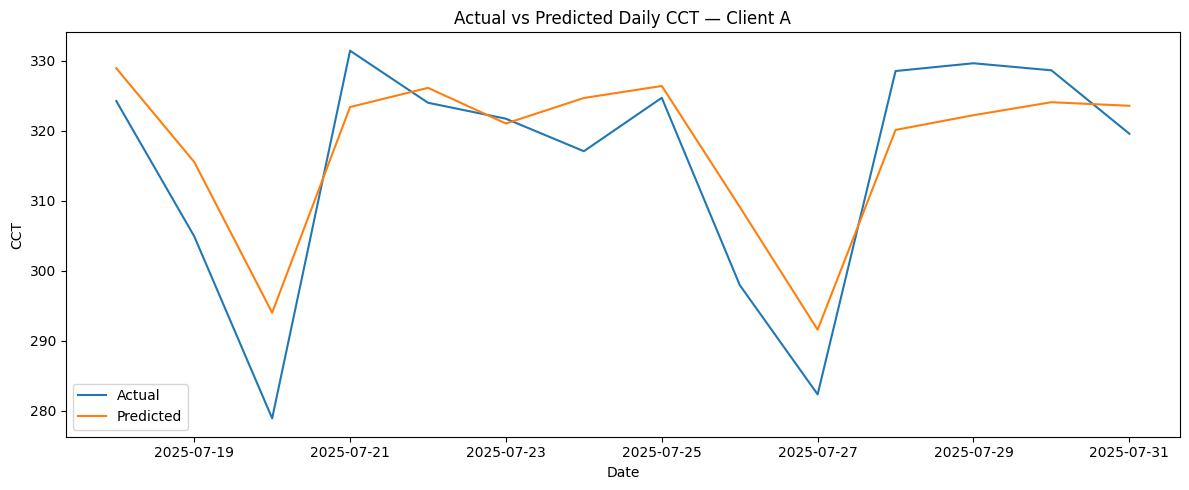

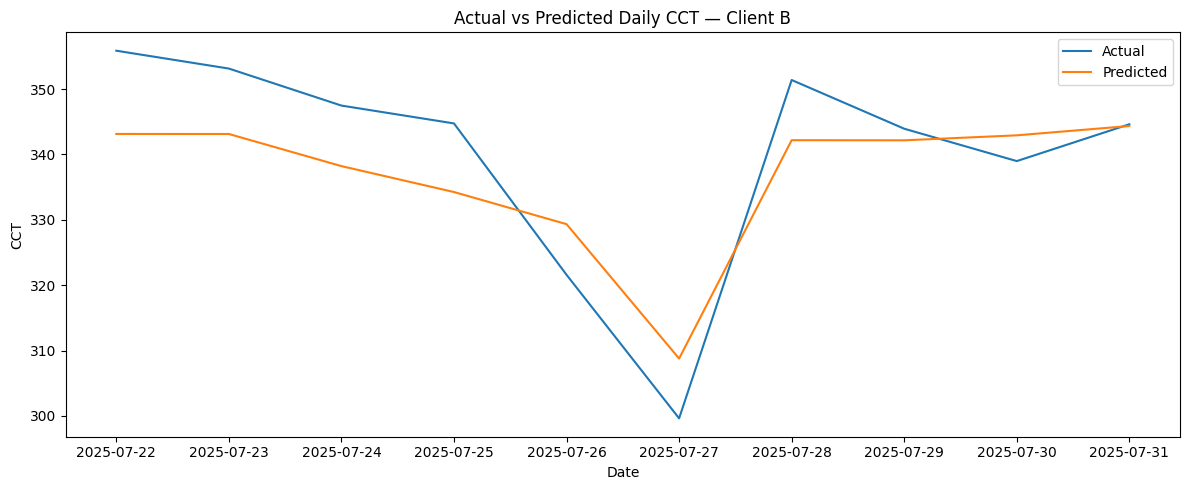

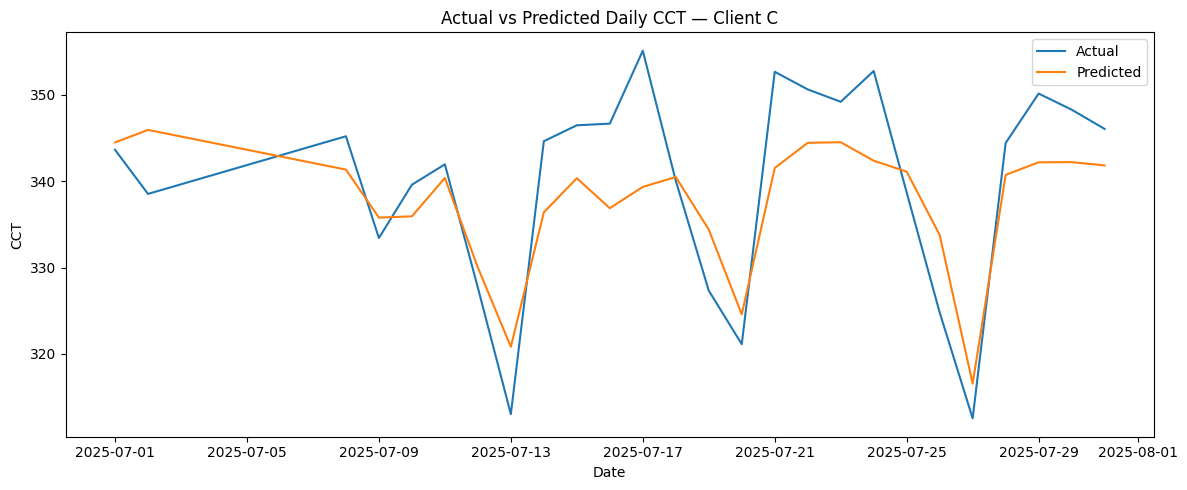

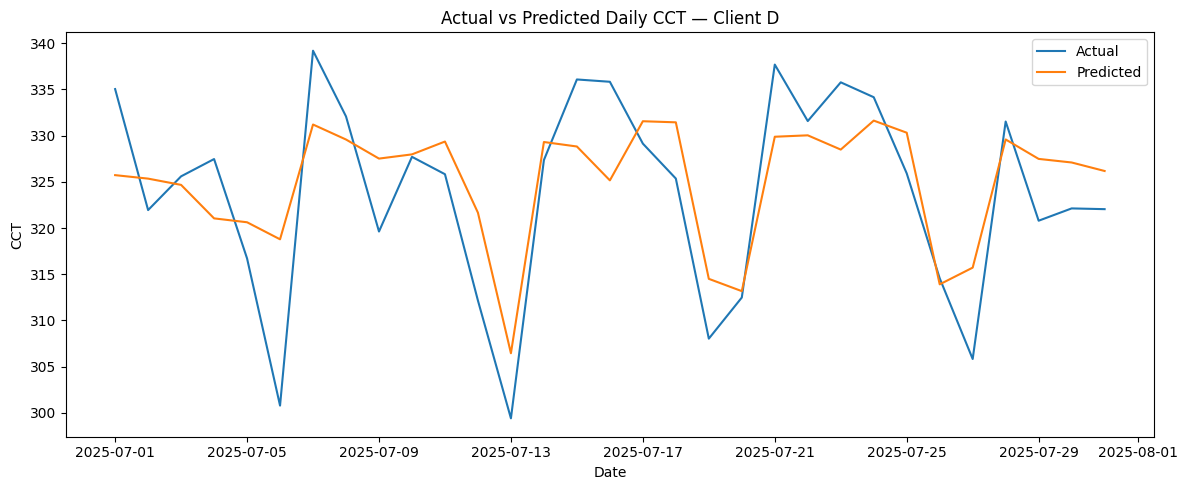

In [52]:
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

for p in portfolios:

    ft = feats[p].copy()
    cols = feat_cols(ft, p)

    ok = ft[cols].notna().all(axis=1) & ft["tgt_CCT"].notna()
    cl = ft.loc[ok].copy()

    train_mask = cl["Date"] < "2025-07-01"
    val_mask = (
        (cl["Date"] >= "2025-07-01") &
        (cl["Date"] < "2025-08-01")
    )

    X_train = cl.loc[train_mask, cols]
    y_train = cl.loc[train_mask, "tgt_CCT"]

    X_val = cl.loc[val_mask, cols]
    y_val = cl.loc[val_mask, "tgt_CCT"]

    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=0.52,
        max_iter=200,
        max_depth=3,
        learning_rate=0.05,
        min_samples_leaf=15,
        l2_regularization=2.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds_val = model.predict(X_val)

    plt.figure(figsize=(12,5))

    plt.plot(
        cl.loc[val_mask, "Date"],
        y_val.values,
        label="Actual"
    )

    plt.plot(
        cl.loc[val_mask, "Date"],
        preds_val,
        label="Predicted"
    )

    plt.title(
        f"Actual vs Predicted Daily CCT — Client {p}"
    )

    plt.xlabel("Date")
    plt.ylabel("CCT")
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"../outputs/client_{p}/daily_cct_actual_vs_pred.png"
    )

    plt.show()

In [53]:

# %%
# -----------------------------
# Save submission
# -----------------------------
rows = []
for day in range(31):
    for slot in range(48):
        h, m = slot // 2, (slot % 2) * 30
        row = {
            "Month": "August",
            "Day": str(day + 1),
            "Interval": f"{h}:{m:02d}"
        }
        for p in portfolios:
            row[f"Calls_Offered_{p}"] = int(res[p]["cv"][day, slot])
            row[f"Abandoned_Calls_{p}"] = int(res[p]["abd"][day, slot])
            row[f"Abandoned_Rate_{p}"] = round(float(res[p]["ar"][day, slot]), 6)
            row[f"CCT_{p}"] = round(float(res[p]["cct"][day, slot]), 2)
        rows.append(row)

sub = pd.DataFrame(rows)[template.columns.tolist()]
out = os.path.join(
    "/Users/trustanprice/Desktop/Personal/illinois-datathon-team015/data/processed/forecast_v39.csv"
)
sub.to_csv(out, index=False)

assert sub.shape == (1488, 19)
assert not sub.isnull().any().any()

for p in portfolios:
    assert (sub[f"Calls_Offered_{p}"] >= 0).all()
    assert (sub[f"Abandoned_Calls_{p}"] <= sub[f"Calls_Offered_{p}"]).all()

print("all assertions passed")
print(f"Saved: {out}")

all assertions passed
Saved: /Users/trustanprice/Desktop/Personal/illinois-datathon-team015/data/processed/forecast_v39.csv
